In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
# Data cleaning

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df['director'].fillna("Unknown", inplace=True)

In [11]:
df['cast'].fillna("Not Available", inplace=True)

In [12]:
df['country'].fillna(df['country'].mode()[0], inplace=True)

In [13]:
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

In [14]:
df['duration'].fillna(df['duration'].mode()[0], inplace=True)

In [16]:
df['date_added'].fillna(method='ffill',inplace=True)

C:\Users\Himanshi Raizada\AppData\Local\Temp\ipykernel_12212\3623466366.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'].fillna(method='ffill',inplace=True)


In [17]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

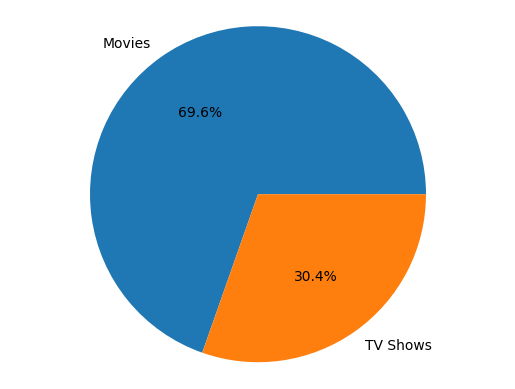

(np.float64(69.6), np.float64(30.4))


In [23]:
#Data visualization

data = df.type
count_tv_shows = data[data == "TV Show"].count()
count_movies = data[data== "Movie"].count()
total = count_movies + count_tv_shows
percentage_movies = (count_movies / total) * 100
percentage_tv_shows = (count_tv_shows / total) * 100

labels = ['Movies', 'TV Shows']
sizes = [percentage_movies, percentage_tv_shows]
plt.pie(sizes, labels=labels, autopct='%.1f%%')
plt.axis('equal')
plt.show()

output = (round(percentage_movies, 1), round(percentage_tv_shows, 1))
print(output)

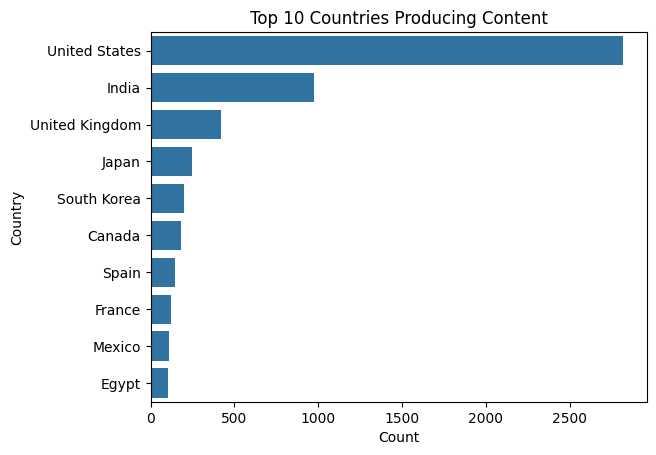

In [25]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

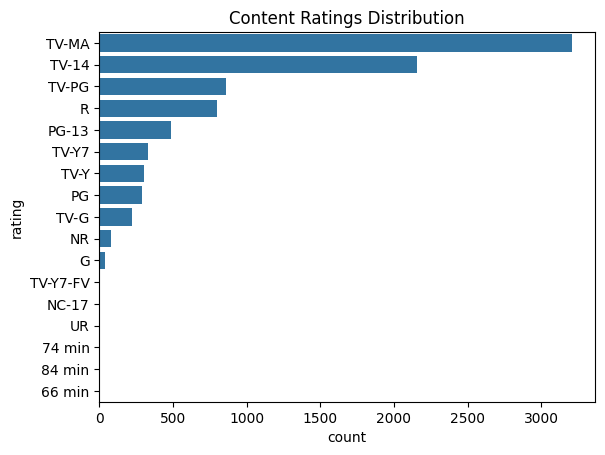

In [7]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

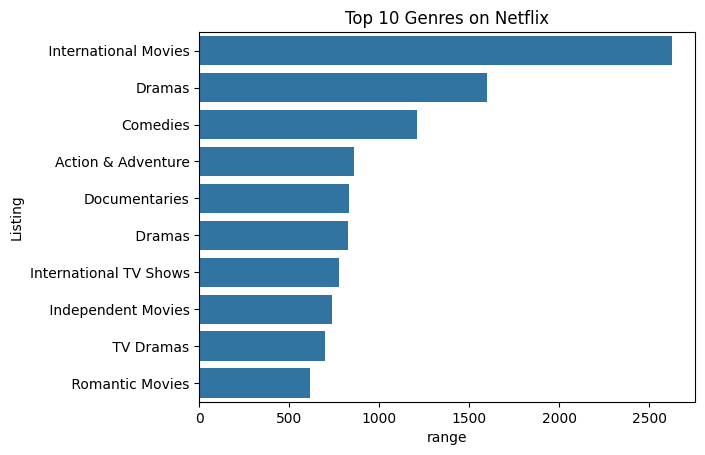

In [8]:
genres = df['listed_in'].str.split(',', expand=True).stack()
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("range")
plt.ylabel("Listing")
plt.show()